In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
import os

print(os.getcwd())
print("\nCSV files in this folder:")
print([file for file in os.listdir() if file.endswith(".csv")])

/Users/kamisettithrailokyabhavani/OIBSIP/DataAnalytics-L1-EDARetailSales

CSV files in this folder:
['retail_sales_analytics_dataset.csv']


In [4]:
import os

print(os.listdir("/Users/kamisettithrailokyabhavani/OIBSIP"))

['DataAnalytics-L1-EDARetailSales']


In [5]:
import pandas as pd
import numpy as np

df_original = pd.read_csv("retail_sales_analytics_dataset.csv")

print("Original Shape:", df_original.shape)
df_original.head()

Original Shape: (1212, 13)


,Transaction ID,Date,Customer Age,Gender,City,Product Category,Product,Unit Price,Quantity,Discount (%),Total Amount,Payment Method,Customer Rating
0,TXN101029,2025-01-01,46,Male,Delhi,Sports,Dumbbells,2182.96,3,5.0,6221.44,UPI,4.1
1,TXN100849,2025-01-01,48,Female,Bengaluru,Electronics,Wireless Earbuds,4460.90,2,15.0,7583.53,UPI,4.0
2,TXN100756,2025-01-01,42,Female,Chennai,Beauty,Shampoo,1910.92,3,10.0,5159.48,Net Banking,2.5
3,TXN100992,2025-01-01,18,Female,Hyderabad,Beauty,Perfume,1992.14,3,0.0,5976.42,Debit Card,3.9
4,TXN100447,2025-01-01,57,Male,Hyderabad,Clothing,Sneakers,3133.38,2,10.0,5640.08,UPI,NaN


In [6]:
df_messy = df_original.copy()

# Introduce missing values
df_messy.loc[5, "Gender"] = np.nan
df_messy.loc[10, "City"] = np.nan
df_messy.loc[15, "Customer Rating"] = np.nan

# Introduce inconsistent formatting
df_messy.loc[20, "Gender"] = "male"
df_messy.loc[21, "Gender"] = "MALE"

# Introduce a duplicate row
df_messy = pd.concat(
    [df_messy, df_messy.iloc[[0]]],
    ignore_index=True
)

print("Messy Dataset Shape:", df_messy.shape)

Messy Dataset Shape: (1213, 13)


In [7]:
df_messy.to_csv("retail_sales_messy.csv", index=False)

print("Messy dataset saved successfully.")

Messy dataset saved successfully.


In [8]:
df = pd.read_csv("retail_sales_messy.csv")

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1213, 13)

Column Names:
['Transaction ID', 'Date', 'Customer Age', 'Gender', 'City', 'Product Category', 'Product', 'Unit Price', 'Quantity', 'Discount (%)', 'Total Amount', 'Payment Method', 'Customer Rating']

Data Types:
Transaction ID          str
Date                    str
Customer Age          int64
Gender                  str
City                    str
Product Category        str
Product                 str
Unit Price          float64
Quantity              int64
Discount (%)        float64
Total Amount        float64
Payment Method          str
Customer Rating     float64
dtype: object


In [9]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values
})

quality_report

,Column,Missing Values,Data Type,Unique Values
0,Transaction ID,0,str,1200
1,Date,0,str,347
2,Customer Age,0,int64,51
3,Gender,1,str,4
4,City,7,str,7
5,Product Category,0,str,5
6,Product,0,str,25
7,Unit Price,0,float64,1200
8,Quantity,0,int64,5
9,Discount (%),6,float64,5


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 13


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

print("\nMinimum values:")
print(df[numeric_columns].min())

print("\nMaximum values:")
print(df[numeric_columns].max())

Numerical Columns:
['Customer Age', 'Unit Price', 'Quantity', 'Discount (%)', 'Total Amount', 'Customer Rating']

Minimum values:
Customer Age        18.00
Unit Price         156.62
Quantity             1.00
Discount (%)         0.00
Total Amount       137.10
Customer Rating      1.20
dtype: float64

Maximum values:
Customer Age           70.00
Unit Price          49973.66
Quantity                5.00
Discount (%)           20.00
Total Amount       211367.07
Customer Rating         5.00
dtype: float64


In [12]:
print("Gender values:")
print(df["Gender"].value_counts(dropna=False))

print("\nPayment Method values:")
print(df["Payment Method"].value_counts(dropna=False))

print("\nProduct Category values:")
print(df["Product Category"].value_counts(dropna=False))

Gender values:
Gender
Female    637
Male      573
NaN         1
male        1
MALE        1
Name: count, dtype: int64

Payment Method values:
Payment Method
UPI            415
Credit Card    308
Debit Card     224
Net Banking    150
Cash           116
Name: count, dtype: int64

Product Category values:
Product Category
Clothing          322
Electronics       298
Home & Kitchen    243
Beauty            200
Sports            150
Name: count, dtype: int64


## Data Cleaning Plan

The dataset was inspected for missing values, duplicate records, inconsistent categorical formatting, incorrect data types, and potential numerical anomalies.

The following cleaning decisions will be applied:

1. **Missing categorical values:** Missing values in categorical columns will be replaced using the mode where appropriate.
2. **Missing numerical values:** Missing numerical values will be handled using the median to reduce the influence of extreme values.
3. **Duplicate records:** Exact duplicate rows will be removed because they represent repeated records.
4. **Inconsistent formatting:** Categorical values such as gender will be standardized to a consistent format.
5. **Date values:** The Date column will be converted to datetime format.
6. **Data types:** Numeric columns will be checked and converted to appropriate numeric data types where necessary.
7. **Outliers:** Numerical columns will be examined using the IQR method. Outliers will be investigated before deciding whether they should be retained or removed.

In [13]:
duplicate_count

np.int64(13)

In [14]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer Age        0
Gender              1
City                7
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        6
Total Amount        0
Payment Method      0
Customer Rating     7
dtype: int64

In [16]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("Rows after duplicate removal:", len(df))
before_rows = len(df)
before_duplicates = df.duplicated().sum()
before_missing = df.isnull().sum().sum()

print("Before Cleaning")
print("----------------")
print("Rows:", before_rows)
print("Duplicate rows:", before_duplicates)
print("Total missing values:", before_missing)

Before Cleaning
----------------
Rows: 1213
Duplicate rows: 13
Total missing values: 21


In [17]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("Rows after duplicate removal:", len(df))

Duplicate rows after removal: 0
Rows after duplicate removal: 1200


In [18]:


df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["City"] = df["City"].fillna(df["City"].mode()[0])

df["Discount (%)"] = df["Discount (%)"].fillna(
    df["Discount (%)"].median()
)

df["Customer Rating"] = df["Customer Rating"].fillna(
    df["Customer Rating"].median()
)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Transaction ID      0
Date                0
Customer Age        0
Gender              0
City                0
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        0
Total Amount        0
Payment Method      0
Customer Rating     0
dtype: int64


In [19]:


df["Gender"] = (
    df["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
)

print(df["Gender"].value_counts())

Gender
Female    632
Male      568
Name: count, dtype: int64


In [20]:


df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df["Date"].dtype)

datetime64[us]


In [21]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer Age        0
Gender              0
City                0
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        0
Total Amount        0
Payment Method      0
Customer Rating     0
dtype: int64

In [22]:
df["Gender"].value_counts()

Gender
Female    632
Male      568
Name: count, dtype: int64

In [23]:
# Identify numerical columns
numeric_columns = [
    "Customer Age",
    "Unit Price",
    "Quantity",
    "Discount (%)",
    "Total Amount",
    "Customer Rating"
]

# Calculate IQR and count outliers
outlier_report = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_report.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_report = pd.DataFrame(outlier_report)

outlier_report

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Customer Age,27.750,43.00,4.8750,65.8750,9
1,Unit Price,1881.630,7543.03,-6610.4700,16035.1300,185
2,Quantity,1.000,3.00,-2.0000,6.0000,0
3,Discount (%),0.000,10.00,-15.0000,25.0000,0
4,Total Amount,2596.135,14124.78,-14696.8325,31417.7475,159
5,Customer Rating,3.500,4.50,2.0000,6.0000,2


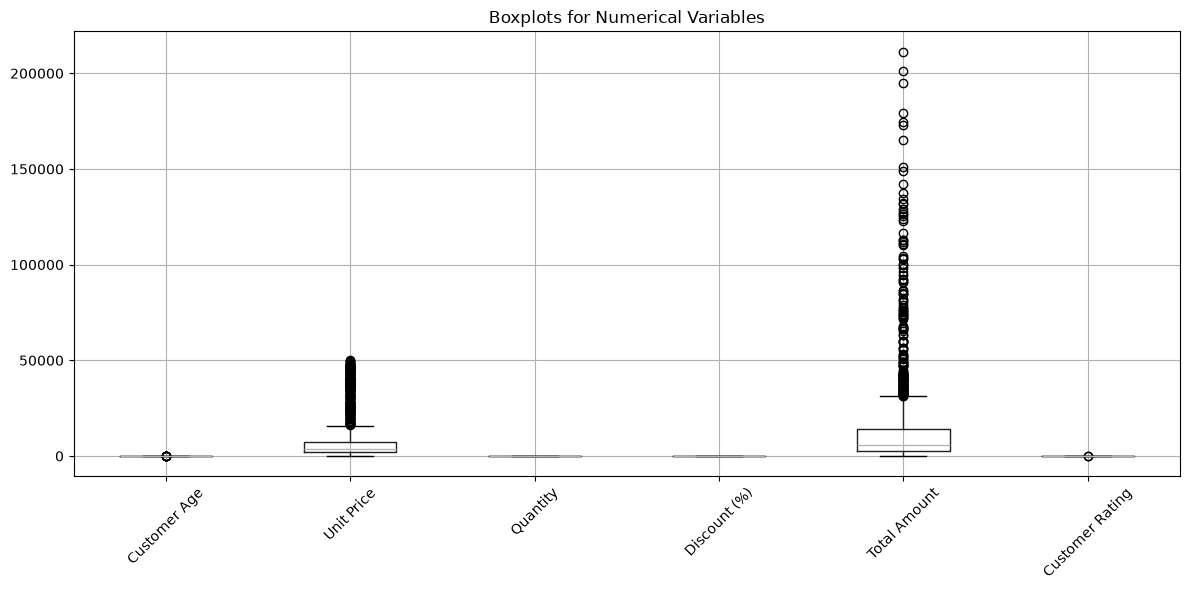

In [24]:
plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title("Boxplots for Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
outlier_report

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Customer Age,27.750,43.00,4.8750,65.8750,9
1,Unit Price,1881.630,7543.03,-6610.4700,16035.1300,185
2,Quantity,1.000,3.00,-2.0000,6.0000,0
3,Discount (%),0.000,10.00,-15.0000,25.0000,0
4,Total Amount,2596.135,14124.78,-14696.8325,31417.7475,159
5,Customer Rating,3.500,4.50,2.0000,6.0000,2


## Outlier Detection and Treatment

The IQR method was used to identify potential outliers in the numerical variables.

The analysis identified potential outliers in Customer Age, Unit Price, Total Amount, and Customer Rating.

These observations were **retained** rather than removed because extreme values in retail transaction data can represent genuine customer purchases, expensive products, or high-value transactions. Removing them could result in the loss of meaningful business information.

The Customer Rating outliers were also retained because the observed values may represent valid ratings within the dataset.

Therefore, the detected outliers were investigated but not removed, as there was no evidence that they represented data-entry errors.

In [26]:
print(df.dtypes)

Transaction ID                 str
Date                datetime64[us]
Customer Age                 int64
Gender                         str
City                           str
Product Category               str
Product                        str
Unit Price                 float64
Quantity                     int64
Discount (%)               float64
Total Amount               float64
Payment Method                 str
Customer Rating            float64
dtype: object


In [27]:
# Correct data types

df["Transaction ID"] = df["Transaction ID"].astype(str)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

numeric_columns = [
    "Customer Age",
    "Unit Price",
    "Quantity",
    "Discount (%)",
    "Total Amount",
    "Customer Rating"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df.dtypes)

Transaction ID                 str
Date                datetime64[us]
Customer Age                 int64
Gender                         str
City                           str
Product Category               str
Product                        str
Unit Price                 float64
Quantity                     int64
Discount (%)               float64
Total Amount               float64
Payment Method                 str
Customer Rating            float64
dtype: object


In [28]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Transaction ID      0
Date                0
Customer Age        0
Gender              0
City                0
Product Category    0
Product             0
Unit Price          0
Quantity            0
Discount (%)        0
Total Amount        0
Payment Method      0
Customer Rating     0
dtype: int64


In [29]:
after_rows = len(df)
after_duplicates = df.duplicated().sum()
after_missing = df.isnull().sum().sum()

comparison = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Duplicate Rows",
        "Total Missing Values"
    ],
    "Before Cleaning": [
        before_rows,
        before_duplicates,
        before_missing
    ],
    "After Cleaning": [
        after_rows,
        after_duplicates,
        after_missing
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Row Count,1213,1200
1,Duplicate Rows,13,0
2,Total Missing Values,21,0


In [30]:
df.to_csv("retail_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Final Data Quality Summary

The data cleaning process successfully improved the quality and consistency of the dataset.

### Before Cleaning
- Rows: 1,213
- Duplicate rows: 13
- Missing values: 21

### After Cleaning
- Rows: 1,200
- Duplicate rows: 0
- Missing values: 0

The duplicate records were removed, missing values were appropriately imputed, categorical values were standardized, dates were converted to datetime format, and numerical columns were checked for potential outliers.

Potential outliers identified using the IQR method were retained because they may represent legitimate retail transactions rather than data-entry errors.

The final dataset is clean, consistent, and ready for further analysis.

## Conclusion

This project demonstrated a complete data-cleaning workflow using Python, pandas, and NumPy.

The dataset initially contained 1,213 rows, 13 duplicate records, and 21 missing values. After cleaning, the dataset contained 1,200 rows with no duplicate records and no missing values.

The cleaning process included missing-value imputation, duplicate removal, categorical data standardization, date conversion, numerical data validation, and IQR-based outlier detection.

The cleaned dataset was saved as `retail_sales_cleaned.csv`, providing an analysis-ready dataset that can be reliably used for further data analysis and visualization.

In [33]:
print("Final Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final Shape: (1200, 13)
Total Missing Values: 0
Duplicate Rows: 0
